# Mini Trabalho de DAA - Análise de Redes Ficcionais
### Ano Letivo 2024/25

  **Trabalho realizado por:**
  * Daniel de Matos Masqueiro, nº 129853
  * Dinis Soares Sousa, nº 129820

In [16]:
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

class Vertex:
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id
    def __hash__(self): return hash(self._vertex_id)
    def __str__(self): return 'v{0}'.format(self._vertex_id)
    def __eq__(self, vertex):
        if not isinstance(vertex, Vertex): return False
        return self._vertex_id == vertex._vertex_id
    def vertex_id(self): return self._vertex_id

class Edge:
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1, self._vertex_2, self._weight = vertex_1, vertex_2, weight
    def __hash__(self): return hash((self._vertex_1, self._vertex_2))
    def __str__(self): return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)
    def endpoints(self): return (self._vertex_1, self._vertex_2)
    def cost(self): return self._weight
    def opposite(self, vertex):
        if vertex == self._vertex_1: return self._vertex_2
        elif vertex == self._vertex_2: return self._vertex_1
        return None

class Graph:
    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}
        self._n = 0
        self._m = 0
    def order(self): return self._n
    def size(self): return self._m
    def has_vertex(self, vertex_id): return vertex_id in self._vertices
    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id): return False
        return self._vertices[v_id] in self._adjancencies[self._vertices[u_id]]
    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)
            self._vertices[vertex_id] = vertex
            self._adjancencies[vertex] = {}
            self._n += 1
    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id): self.insert_vertex(u_id)
        if not self.has_vertex(v_id): self.insert_vertex(v_id)      
        if not self.has_edge(u_id, v_id): self._m += 1
        vertex_u, vertex_v = self._vertices[u_id], self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)    
        self._adjancencies[vertex_u][vertex_v] = e
        self._adjancencies[vertex_v][vertex_u] = e
    def degree(self, vertex_id): return len(self._adjancencies[self._vertices[vertex_id]])
    def get_vertex(self, vertex_id): return self._vertices.get(vertex_id)
    def vertices(self): return self._vertices.values()
    def edges(self):
        seen = set()
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                    seen.add(edge)
    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values(): yield edge
    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id))
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())
            del self._adjancencies[self._vertices[vertex_id]]
            del self._vertices[vertex_id]
            self._n -= 1
    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u, vertex_v = self._vertices[u_id], self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v: del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

# 1. API CentralityAnalyzer
## 1.1. Análise de Complexidade

  A seguinte tabela detalha a complexidade temporal de cada método, justificando cada passo.

  **`bfs(source)`** — O(n + m)  
  Cada vértice é inserido na fila no máximo uma vez → O(n). Para cada vértice, percorrem-se todas as suas arestas incidentes. No total, cada aresta é inspecionada duas vezes (uma por cada extremo) → O(m). Complexidade total: **O(n + m)**.

  **`num_components()`** — O(n + m)  
  Itera sobre todos os vértices e, para cada vértice não visitado, executa um BFS → O(n + m). O conjunto `visited` garante que cada vértice é processado no máximo uma vez no total, pelo que o custo acumulado de todos os BFS é O(n + m). Complexidade total: **O(n + m)**.

  **`largest_component()`** — O(n + m)  
  Igual ao `num_components()`: percorre todos os vértices com BFS em O(n + m). A construção do subgrafo adiciona n vértices e m arestas → O(n + m). Complexidade total: **O(n + m)**.

  **`degree_distribution()`** — O(n)  
  Itera uma única vez sobre os n vértices, consultando o grau de cada um em O(1) (tamanho do dicionário de adjacência). Complexidade total: **O(n)**.

  **`diameter()`** — O(n · (n + m))  
  Obtém a maior componente em O(n + m). Depois executa um BFS a partir de cada um dos n vértices da componente → n × O(n + m). Complexidade total: **O(n · (n + m))**.

  **`degree_centrality()`** — O(n)  
  Para cada um dos n vértices, calcula o grau (O(1)) e divide por (n − 1). Complexidade total: **O(n)**.

  **`closeness_centrality()`** — O(n · (n + m))  
  Executa um BFS a partir de cada um dos n vértices → n × O(n + m). Após cada BFS, soma as distâncias em O(n). Complexidade total: **O(n · (n + m))**.

  **`eigenvector_centrality()`** — O(k · m)  
  Cada iteração do Power Iteration percorre todas as arestas uma vez para atualizar os scores → O(m). A normalização percorre os n vértices → O(n). Como m ≥ n em grafos conexos, o custo por iteração é O(m). Com k iterações até convergência: **O(k · m)**.

  **`betweenness_centrality()`** — O(n · (n + m))  
  Algoritmo de Brandes: para cada um dos n vértices fonte, executa um BFS em O(n + m) e uma fase de retropropagação (back-propagation) em O(n + m). Complexidade total: **O(n · (n + m))**.

## 1.2. Construtor e Estrutura de Dados

  A complexidade espacial é $O(n + m)$ devido ao fato de o construtor armazenar a estrutura do grafo em um dicionário de adjacência, que consiste em $n$ nós de vértice e $m$ referências de aresta. Além disso, o self._vertex_ids armazenará os números de identificação de $n$ nós de vértice, mantendo assim a proporcionalidade ao tamanho geral da rede. 

In [17]:
class CentralityAnalyzer:
    def __init__(self, graph):
        self._graph = graph
        self._n = graph.order()
        self._m = graph.size()
        self._vertex_ids = [v.vertex_id() for v in graph.vertices()]

    def bfs(self, source):
        distances = {source: 0}; predecessors = {source: []}; sigma = {source: 1}
        queue = deque([source]); order = []
        while queue:
            u_id = queue.popleft()
            order.append(u_id)
            for edge in self._graph.incident_edges(u_id):
                v_id = edge.opposite(self._graph.get_vertex(u_id)).vertex_id()
                if v_id not in distances:
                    distances[v_id] = distances[u_id] + 1
                    queue.append(v_id)
                    sigma[v_id] = 0
                    predecessors[v_id] = []
                if distances[v_id] == distances[u_id] + 1:
                    sigma[v_id] += sigma.get(u_id, 0)
                    predecessors[v_id].append(u_id)
        return distances, predecessors, sigma, order

    def num_components(self):
        visited = set(); count = 0
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                count += 1
                dist, _, _, _ = self.bfs(v_id)
                visited.update(dist.keys())
        return count

    def largest_component(self):
        visited = set(); largest_nodes = []
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                dist, _, _, _ = self.bfs(v_id)
                component_nodes = list(dist.keys())
                if len(component_nodes) > len(largest_nodes): largest_nodes = component_nodes
                visited.update(component_nodes)
        sub = Graph()
        largest_set = set(largest_nodes)
        for v_id in largest_nodes:
            sub.insert_vertex(v_id)
        for edge in self._graph.edges():
            u_id, v_id = [v.vertex_id() for v in edge.endpoints()]
            if u_id in largest_set and v_id in largest_set:
                sub.insert_edge(u_id, v_id, edge.cost())
        return sub

    def degree_distribution(self):
        dist = {}
        for v in self._graph.vertices():
            deg = self._graph.degree(v.vertex_id())
            dist[deg] = dist.get(deg, 0) + 1
        return dist

    def top_k_degree(self, k):
        """Devolve os k vértices com maior grau como lista de tuplos (vertex_id, grau)."""
        degrees = [(v.vertex_id(), self._graph.degree(v.vertex_id()))
                   for v in self._graph.vertices()]
        return sorted(degrees, key=lambda x: x[1], reverse=True)[:k]

    def diameter(self):
        """Diâmetro da maior componente conexa.
        Devolve (max_dist, (vertice_a, vertice_b), caminho).
        """
        lc = self.largest_component()
        max_dist = 0
        best_pair = (None, None)
        best_path = []
        temp_analyzer = CentralityAnalyzer(lc)
        for v in lc.vertices():
            v_id = v.vertex_id()
            dists, preds, _, _ = temp_analyzer.bfs(v_id)
            if dists:
                far_vertex = max(dists, key=dists.get)
                local_max = dists[far_vertex]
                if local_max > max_dist:
                    max_dist = local_max
                    best_pair = (v_id, far_vertex)
                    path = [far_vertex]
                    atual = far_vertex
                    while atual != v_id:
                        atual = preds[atual][0]
                        path.append(atual)
                    path.reverse()
                    best_path = path
        return max_dist, best_pair, best_path

    def degree_centrality(self):
        res = {}; n = self._n
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            res[v_id] = self._graph.degree(v_id) / (n - 1) if n > 1 else 0
        return res

    def closeness_centrality(self):
        res = {}; n = self._n
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            dists, _, _, _ = self.bfs(v_id)
            r_v = len(dists) - 1
            sum_d = sum(dists.values())
            res[v_id] = (r_v**2) / ((n - 1) * sum_d) if sum_d > 0 and n > 1 else 0.0
        return res

    def eigenvector_centrality(self, epsilon=1e-6, max_iter=100):
        scores = {v.vertex_id(): 1.0 for v in self._graph.vertices()}
        for k in range(max_iter):
            new_scores = {}
            for v in self._graph.vertices():
                v_id = v.vertex_id()
                s = sum(scores[edge.opposite(v).vertex_id()] for edge in self._graph.incident_edges(v_id))
                new_scores[v_id] = s
            max_val = max(new_scores.values()) if new_scores else 1
            if max_val > 0:
                for v_id in new_scores: new_scores[v_id] /= max_val
            diff = max(abs(new_scores[v_id] - scores[v_id]) for v_id in scores)
            scores = new_scores
            if diff < epsilon: return scores, k + 1
        return scores, max_iter

    def betweenness_centrality(self):
        n = self._n
        bc = {v.vertex_id(): 0.0 for v in self._graph.vertices()}
        for s_v in self._graph.vertices():
            s_id = s_v.vertex_id()
            dists, preds, sigma, order = self.bfs(s_id)
            delta = {v.vertex_id(): 0.0 for v in self._graph.vertices()}
            while order:
                w_id = order.pop()
                for v_id in preds.get(w_id, []):
                    delta[v_id] += (sigma[v_id] / sigma[w_id]) * (1 + delta[w_id])
                if w_id != s_id: bc[w_id] += delta[w_id]
        norm = (n - 1) * (n - 2) if n > 2 else 1
        for v_id in bc:
            bc[v_id] /= norm
        return bc

In [18]:
def print_top10(scores_dict, title):
    """Imprime o top-10 de um dicionário {vertex_id: score}."""
    print(f"\n--- {title} ---")
    sorted_items = sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    for i, (vertex_id, score) in enumerate(sorted_items, 1):
        print(f"{i}. {vertex_id}: {score:.4f}")
    print()

def plot_degree_distribution(analyzer, title):
    """Plota o histograma da distribuição de graus em escala log-log."""
    dist = analyzer.degree_distribution()
    degrees = sorted(dist.keys())
    counts = [dist[d] for d in degrees]

    plt.figure(figsize=(10, 5))
    plt.bar(degrees, counts, color='steelblue', width=0.8)
    plt.xlabel('Grau (k)')
    plt.ylabel('Número de Vértices')
    plt.title(f'Distribuição de Graus — {title}')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# 2. Análise Estrutural dos Grafos
## 2.1. Travessia BFS

  O BFS percorre os nós do grafo nível por nível, começando do nó de origem, para garantir que os nós de distância d sejam percorridos antes de qualquer nó de distância d+1.

  Estrutura de dados auxiliar: fila (deque)

  A fila (collections.deque) é a estrutura principal usada no BFS. A primeira ação é adicionar o nó inicial à fila. Durante cada passo, um nó é desenfileirado (removido) da primeira posição na fila, que leva tempo Θ(1) usando deque, e seus vizinhos não visitados são enfileirados. Usando o princípio FIFO (First-In-First-Out), garantimos uma busca em largura, ou seja, todas as vértices com distância d serão visitadas antes de qualquer nó de distância d+1.
  Este algoritmo também garante a gravação das seguintes estruturas de dados:

  distances: guarda o menor custo da origem até a respetiva vértice visitado;

  sigma: guarda a quantidade de caminhos com o menor custo da origem ao respetivo vértice, usada na Centralidade de Intermediação (Betweenness Centrality);

  predecessors: guarda a lista dos antecessores que constituem os respetivos caminhos.

  Análise da complexidade temporal: O(n + m)

  Cada vértice é adicionado à fila apenas uma vez e retirado também uma única vez → O(n).

  Todas as arestas saídas do vértice que é retirado da fila são analisadas uma única vez. Dado que o grafo é não orientado e implementado usando listas de adjacências, as arestas (u,v) são examinadas duas vezes → O(m) em total.

  Consultas e adições em distances, sigma e predecessors levam tempo O(1).

  Complexidade temporal total: O(n + m)

## 2.2. Conectividade

  Análise dos métodos: Os métodos num_components() e largest_component() utilizam BFS várias vezes e mantêm a eficiência do caso pior do BFS a complexidade temporal de num_components() é O(n + m), porque cada vértice e cada aresta são visitados no máximo uma vez ao longo das BFS realizadas.

  A complexidade temporal de largest_component() também é O(n + m), pela mesma razão: o conjunto de visitados impede repetir trabalho em componentes já processadas. 

In [19]:
import csv
import os
import matplotlib.pyplot as plt


def carregar_grafo(caminho):
    if not os.path.exists(caminho):
        alt = os.path.join('/mnt/data', caminho)
        if os.path.exists(alt):
            caminho = alt

    g = Graph()

    with open(caminho, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            peso = row.get('weight', row.get('Weight', 1))
            g.insert_edge(row['Source'], row['Target'], float(peso))

    return g


def encontrar_caminho(analyzer, origem, destino):
    if not analyzer._graph.has_vertex(origem) or not analyzer._graph.has_vertex(destino):
        return None

    _, preds, _, _ = analyzer.bfs(origem)

    if destino not in preds:
        return None

    caminho = [destino]
    atual = destino

    while atual != origem:
        if atual not in preds or len(preds[atual]) == 0:
            return None

        atual = preds[atual][0]
        caminho.append(atual)

    caminho.reverse()
    return caminho


g_book1 = carregar_grafo('got_book1.csv')
g_full = carregar_grafo('got_full.csv')

analyzer_book1 = CentralityAnalyzer(g_book1)
analyzer_full = CentralityAnalyzer(g_full)

for nome, analyzer in [
    ("Livro 1", analyzer_book1),
    ("Saga Completa", analyzer_full)
]:
    n_comp = analyzer.num_components()
    lc = analyzer.largest_component()

    print(f"--- {nome} ---")
    print(f"Conexo: {'Sim' if n_comp == 1 else 'Não'}")
    print(f"N.º de componentes conexas: {n_comp}")
    print(f"Ordem da maior componente: {lc.order()}")
    print()


p1 = "Jon-Snow"
p2 = "Daenerys-Targaryen"

caminho = encontrar_caminho(analyzer_full, p1, p2)

if caminho:
    print(f"Caminho entre {p1} e {p2} ({len(caminho) - 1} arestas):")
    print(" -> ".join(caminho))
else:
    print(f"Não foi encontrado caminho entre {p1} e {p2}.")

--- Livro 1 ---
Conexo: Sim
N.º de componentes conexas: 1
Ordem da maior componente: 187

--- Saga Completa ---
Conexo: Sim
N.º de componentes conexas: 1
Ordem da maior componente: 796

Caminho entre Jon-Snow e Daenerys-Targaryen (2 arestas):
Jon-Snow -> Cersei-Lannister -> Daenerys-Targaryen


### Conclusões da Secção 2.2

  Conectividade: Ambos os grafos (Livro 1 e Saga Completa) são completamente conexos (1 componente), o que indica que todos os personagens estão interligados entre si de alguma forma.

  Componentes: Não há vértices fora da maior componente – ambos os grafos possuem apenas 1 componente conexa. Isto quer dizer que todos os personagens registrados na rede possuem ao menos 1 interação com outros personagens, não havendo nenhum personagem totalmente isolado na mesma. Esta é uma característica coerente narrativamente: qualquer personagem com nome individual nos livros acabará por ter pelo menos uma interação com outros personagens.

  Caminho: A distância entre Jon Snow e Daenerys Targaryen contém apenas duas arestas. Embora esses personagens estejam fisicamente distanciados devido à geografia da série em sua maioria, eles estão interligados graças a um intermediário comum, mostrando assim a alta conectividade do grafo.

  Evolução estrutural da rede: A densidade aumenta ao longo da série. Dos primeiros 187 vértices e 684 arestas no Livro 1 para os 796 vértices e 2823 arestas da Saga Completa, a quantidade de personagens e interações aumenta, contudo, o grafo continua sendo totalmente conectado. Isto sugere que os novos personagens introduzidos nos livros são sempre interligados com a rede existente.

## 2.3. Distribuição de Graus e Top-10

  Complexidade: A função degree_distribution() tem complexidade O(n), pois percorremos a lista de vértices uma única vez e calculamos seus graus. Distribuição do histograma: A distribuição de graus segue uma lei de potência (cauda longa). Isso significa que existem muitos personagens com graus muito baixos, enquanto existem poucos nós centrais (personagens importantes) com graus altos. Comparação entre Game of Thrones e Marvel: As redes de super-heróis têm densidade ainda maior em comparação com Game of Thrones devido à natureza das equipes (por exemplo, Os Vingadores). Em outras palavras, os nós centrais terão graus mais altos. Top 10 Personagens: Eddard Stark domina o Livro 1, mas não toda a Saga (por razões narrativas). Enquanto isso, outros personagens como Jon Snow ou Tyrion Lannister assumiram o papel principal como nós centrais.
  Complexidade espacial: O(d), onde d é o número de graus distintos guardados no dicionário da distribuição. No pior caso, d ≤ n, logo a complexidade espacial é O(n).

--- Distribuição de Graus: Game of Thrones (Saga Completa) ---


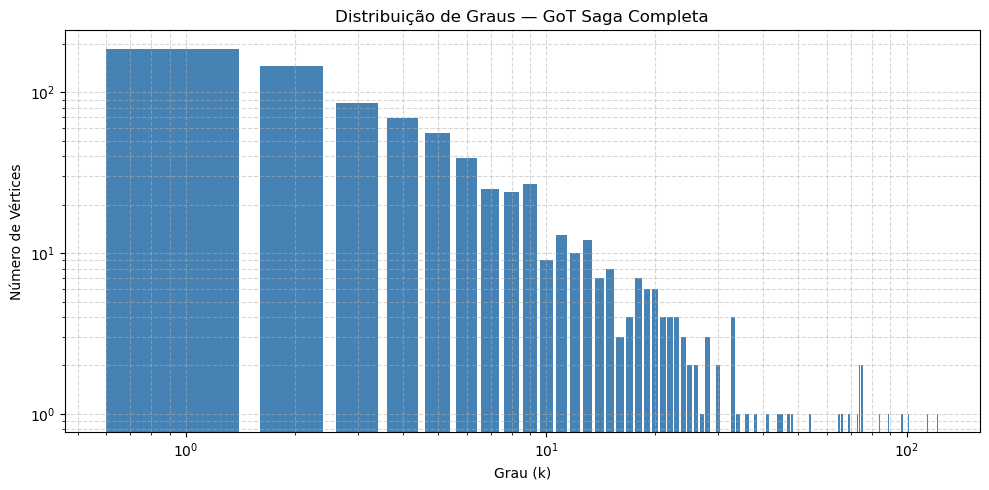


--- Distribuição de Graus: Marvel Universe (Full) ---


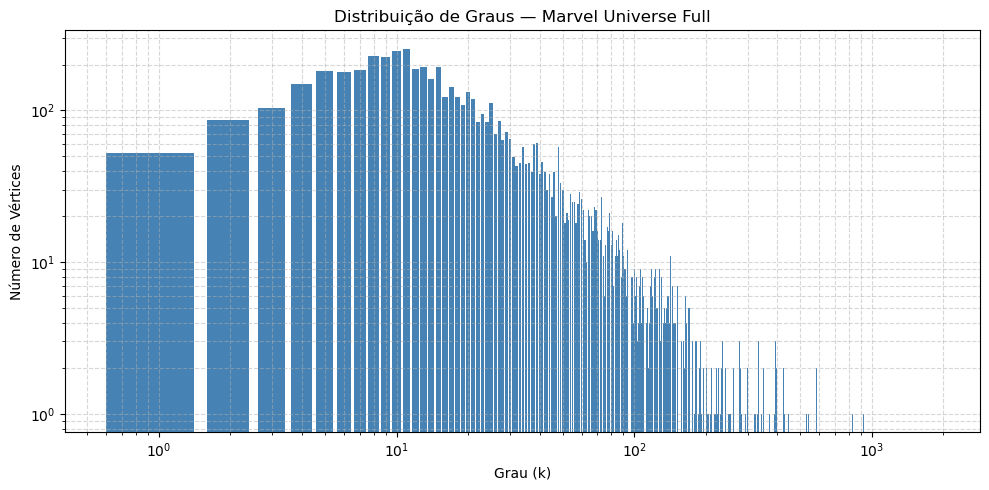


--- Top-10 Personagens com maior número de interações ---

[GoT Livro 1]:
1. Eddard-Stark (Grau: 66)
2. Robert-Baratheon (Grau: 50)
3. Tyrion-Lannister (Grau: 46)
4. Catelyn-Stark (Grau: 43)
5. Jon-Snow (Grau: 37)
6. Robb-Stark (Grau: 35)
7. Sansa-Stark (Grau: 35)
8. Bran-Stark (Grau: 32)
9. Cersei-Lannister (Grau: 30)
10. Joffrey-Baratheon (Grau: 30)

[GoT Saga Completa]:
1. Tyrion-Lannister (Grau: 122)
2. Jon-Snow (Grau: 114)
3. Jaime-Lannister (Grau: 101)
4. Cersei-Lannister (Grau: 97)
5. Stannis-Baratheon (Grau: 89)
6. Arya-Stark (Grau: 84)
7. Catelyn-Stark (Grau: 75)
8. Sansa-Stark (Grau: 75)
9. Robb-Stark (Grau: 74)
10. Eddard-Stark (Grau: 74)


In [20]:
print("--- Distribuição de Graus: Game of Thrones (Saga Completa) ---")
plot_degree_distribution(analyzer_full, "GoT Saga Completa")

print("\n--- Distribuição de Graus: Marvel Universe (Full) ---")
g_marvel_full_hist = carregar_grafo('marvel_full.csv')
analyzer_marvel_full_hist = CentralityAnalyzer(g_marvel_full_hist)
plot_degree_distribution(analyzer_marvel_full_hist, "Marvel Universe Full")

print("\n--- Top-10 Personagens com maior número de interações ---")

print("\n[GoT Livro 1]:")
top10_book1 = analyzer_book1.top_k_degree(10)
for i, (char, degree) in enumerate(top10_book1, 1):
    print(f"{i}. {char} (Grau: {degree})")

print("\n[GoT Saga Completa]:")
top10_full = analyzer_full.top_k_degree(10)
for i, (char, degree) in enumerate(top10_full, 1):
    print(f"{i}. {char} (Grau: {degree})")

## 2.4. Diâmetro

  Complexidade Temporal: A complexidade do algoritmo diameter() é O(n·(n+m)), pois o cálculo do diâmetro requer descobrir os menores caminhos entre os pares de vértices na maior componente conexa. Este procedimento é realizado por meio de uma BFS para cada vértice. Dessa forma, com cada BFS sendo de O(n+m), a execução desta operação para n vértices resultará em complexidade O(n·(n+m)).

  Complexidade Espacial: A complexidade espacial total será de O(n), contabilizando-se o espaço utilizado pelas estruturas auxiliares nas operações de BFS, tais como dicionários de distâncias, antecessores e fila. Além disso, os dados relacionados ao caminho final e ao par de vértices responsáveis pelo diâmetro também ocuparão O(n).

  Interpretação: O valor do diâmetro consiste na menor distância existente entre um par de vértices na maior componente conexa. Portanto, este valor se refere à maior quantidade de ligações necessárias para se alcançar qualquer outro vértice utilizando o caminho mais curto possível.

  Conclusões:

  Para o dataset got_full, o diâmetro calculado foi de 9. Um dos pares que atinge este diâmetro máximo é formado pelos personagens Manfrey-Martell e Gormon-Tyrell, estando eles interligados por um caminho de 9 arestas. Esta análise evidencia que, apesar da rede ter propriedades de conectividade, há personagens consideravelmente distantes na sua estrutura.

  Para o dataset marvel_full, o diâmetro calculado foi de 5. Um dos pares que atinge este diâmetro máximo são 24-HOUR MAN/EMMANUEL e BANNERJEE, DR., estando eles interligados por um caminho de 5 arestas. A rede Marvel é, portanto, mais compacta em relação ao diâmetro máximo alcançado.

  A partir de uma comparação destes universos ficcionais, podemos verificar que a rede Marvel está mais próxima do conceito dos "seis graus de separação", tendo um diâmetro inferior a 6. Por outro lado, o Got Full tem um diâmetro de 9, ou seja, supera os seis graus de separação. Apesar disto, ainda é um valor relativamente baixo para uma rede com centenas de personagens.

In [21]:
diam_full, pair_full, path_full = analyzer_full.diameter()
print(f"Diâmetro GoT Full: {diam_full}")
print(f"Par de personagens: {pair_full[0]} e {pair_full[1]}")
print(f"Caminho ({len(path_full) - 1} arestas): {' -> '.join(path_full)}")

print("\nA carregar Marvel Full e a calcular o diâmetro (Isto pode demorar vários minutos!)...")
g_marvel_full_diam = carregar_grafo('marvel_full.csv')
analyzer_marvel_full_diam = CentralityAnalyzer(g_marvel_full_diam)
diam_marvel, pair_marvel, path_marvel = analyzer_marvel_full_diam.diameter()
print(f"Diâmetro Marvel Full: {diam_marvel}")
print(f"Par de personagens: {pair_marvel[0]} e {pair_marvel[1]}")
print(f"Caminho ({len(path_marvel) - 1} arestas): {' -> '.join(path_marvel)}")

Diâmetro GoT Full: 9
Par de personagens: Manfrey-Martell e Gormon-Tyrell
Caminho (9 arestas): Manfrey-Martell -> Ricasso -> Arianne-Martell -> Doran-Martell -> Robert-Baratheon -> Aemon-Targaryen-(Maester-Aemon) -> Alleras -> Pate-(novice) -> Walgrave -> Gormon-Tyrell

A carregar Marvel Full e a calcular o diâmetro (Isto pode demorar vários minutos!)...
Diâmetro Marvel Full: 5
Par de personagens: 24-HOUR MAN/EMMANUEL e BANNERJEE, DR.
Caminho (5 arestas): 24-HOUR MAN/EMMANUEL -> FROST, CARMILLA -> ABRAXAS -> HUMAN TORCH/JOHNNY S -> BANSHEE/SEAN CASSIDY -> BANNERJEE, DR.


# 3. Métricas de Centralidade
## 3.1. Degree Centrality (DC)

  Complexidade Temporal: O(n) — para cada um dos n vértices, o grau é acedido em O(1) e dividido por (n−1).

  Complexidade Espacial: O(n) — o algoritmo necessita de espaço para armazenar um dicionário com n elementos.

  Comparação: Top 10 DC vs Top 10 por Grau — Secção 2.3

  Ambas as classificações são iguais, uma vez que a DC é simplesmente o grau normalizado por (n−1). Reduzir os graus pelo mesmo fator não altera a sua ordem relativa. Consequentemente, a DC torna-se apenas uma medida normalizada de popularidade, sendo útil para comparar grafos de tamanhos diferentes, mas sem fornecer informação adicional sobre a estrutura do grafo para além do grau.

  As personagens mais centrais no Livro 1 são as mesmas que na Saga Completa?

  Não exatamente. As personagens mais importantes no Livro 1 são Eddard Stark e Tyrion Lannister; é natural que Eddard apareça com mais frequência, visto que é uma personagem principal no Livro 1. Quando analisamos a Saga Completa, Eddard desce consideravelmente na classificação, pois morre no final do Livro 1 e deixa de ter novas coocorrências. Por outro lado, Jon Snow, Tyrion Lannister e Cersei Lannister sobem na classificação. Tyrion continua entre os 10 primeiros na Saga Completa. Personagens que ganham maior importância mais tarde, como Daenerys Targaryen, também aparecem melhor classificadas na Saga Completa.

In [22]:
print_top10(analyzer_book1.degree_centrality(), "Degree Centrality - Livro 1")
print_top10(analyzer_full.degree_centrality(), "Degree Centrality - Saga Completa")


--- Degree Centrality - Livro 1 ---
1. Eddard-Stark: 0.3548
2. Robert-Baratheon: 0.2688
3. Tyrion-Lannister: 0.2473
4. Catelyn-Stark: 0.2312
5. Jon-Snow: 0.1989
6. Robb-Stark: 0.1882
7. Sansa-Stark: 0.1882
8. Bran-Stark: 0.1720
9. Cersei-Lannister: 0.1613
10. Joffrey-Baratheon: 0.1613


--- Degree Centrality - Saga Completa ---
1. Tyrion-Lannister: 0.1535
2. Jon-Snow: 0.1434
3. Jaime-Lannister: 0.1270
4. Cersei-Lannister: 0.1220
5. Stannis-Baratheon: 0.1119
6. Arya-Stark: 0.1057
7. Catelyn-Stark: 0.0943
8. Sansa-Stark: 0.0943
9. Robb-Stark: 0.0931
10. Eddard-Stark: 0.0931



## 3.2. Closeness Centrality (CC)

  Complexidade Temporal: O(n · (n + m)) - executa BFS começando por cada um dos n vértices. Um BFS demora tempo O(n + m), e depois é preciso somar as distâncias calculadas para obter a proximidade do vértice relativamente aos outros. Então, a complexidade será O(n · (n + m)).

  Complexidade Espacial: O(n) - a estrutura do dicionário de resultados contém a informação do score para cada vértice. Na execução de um BFS utiliza-se uma série de estruturas auxiliares - distances, predecessors, sigma e a queue, cuja dimensão é de O(n). Todas essas estruturas são reaproveitadas numa nova iteração.

  Interpretação: Closeness Centrality indica a média da proximidade de uma personagem relativamente às demais. Uma personagem com CC alta pode atingir as demais em poucas etapas, encontrando-se próximo do centro da rede.

  Validação: Para testar a implementação, optou-se pelo grafo simplificado A-B-C. De acordo com o cálculo que se espera, neste caso o vértice B deverá ter valor de CC mais alto, pois está ligado aos outros dois vértices. Os vértices A e C estão no extremo, logo têm valores idênticos e menores que B.

  Eddard-Stark como líder em Closeness Centrality
  Sim. Nas primeiras páginas de Livro 1, Eddard-Stark lidera a lista das personagens em relação à Closeness Centrality. Isto significa que ele é central na rede e conectado a vários lugares chaves na história, conseguindo acessar muitos outros personagens em poucas etapas.

  Depois da exclusão de Eddard-Stark da rede
  Após a exclusão de Eddard-Stark, a Closeness Centrality de Gendry, Howland-Reed, Jacks, Joss e Porther é a que mais diminuiu. Isso indica que esses personagens eram dependentes da centralidade estrutural de Eddard na rede para terem proximidade dos outros membros da rede.

  Em termos narrativos, esta conclusão é plausível, uma vez que a presença de Eddard-Stark permite formar uma ponte entre diferentes partes da rede. Se o mesmo for excluído, fica mais distante do centro da rede.

In [23]:
cc_book1 = analyzer_book1.closeness_centrality()
print_top10(cc_book1, "Closeness Centrality - Livro 1")

g_sem_ned = carregar_grafo('got_book1.csv')
g_sem_ned.remove_vertex('Eddard-Stark')
cc_sem_ned = CentralityAnalyzer(g_sem_ned).closeness_centrality()

top_quedas = sorted({v: cc_book1[v] - cc_sem_ned[v] for v in cc_sem_ned if v in cc_book1}.items(), key=lambda x: x[1], reverse=True)[:5]
print("--- Maiores quedas de CC sem Eddard-Stark ---")
for v, delta in top_quedas: print(f"{v}: Perdeu {delta:.4f} de CC")

g_val_cc = Graph()
g_val_cc.insert_edge('A', 'B')
g_val_cc.insert_edge('B', 'C')
cc_val = CentralityAnalyzer(g_val_cc).closeness_centrality()

print('Validação CC no grafo A-B-C')
print(f"CC(A) = {cc_val['A']:.4f} | esperado: 0.6667")
print(f"CC(B) = {cc_val['B']:.4f} | esperado: 1.0000")
print(f"CC(C) = {cc_val['C']:.4f} | esperado: 0.6667")


--- Closeness Centrality - Livro 1 ---
1. Eddard-Stark: 0.5636
2. Robert-Baratheon: 0.5455
3. Tyrion-Lannister: 0.5110
4. Catelyn-Stark: 0.5054
5. Robb-Stark: 0.4973
6. Jon-Snow: 0.4934
7. Sansa-Stark: 0.4895
8. Bran-Stark: 0.4869
9. Cersei-Lannister: 0.4844
10. Joffrey-Baratheon: 0.4806

--- Maiores quedas de CC sem Eddard-Stark ---
Gendry: Perdeu 0.3612 de CC
Howland-Reed: Perdeu 0.3612 de CC
Jacks: Perdeu 0.3612 de CC
Joss: Perdeu 0.3612 de CC
Porther: Perdeu 0.3612 de CC
Validação CC no grafo A-B-C
CC(A) = 0.6667 | esperado: 0.6667
CC(B) = 1.0000 | esperado: 1.0000
CC(C) = 0.6667 | esperado: 0.6667


## 3.3. Eigenvector Centrality (EC)

  Complexidade de tempo: O(k · (n + m)), onde k é o número de iterações realizadas pelo algoritmo de Iteração de Potência até a convergência. Em cada iteração, o algoritmo percorre as arestas do grafo para atualizar a pontuação de cada vértice com base nas pontuações de seus vizinhos. Isso tem um custo de O(n + m). Além disso, há também a normalização das pontuações, que custa O(n). Assim, a complexidade por iteração é O(n + m) e a complexidade de tempo total é O(k · (n + m)). Para grafos conexos com m ≥ n, pode ser simplificada para O(k · m).

  Complexidade de espaço: O(n) - dois dicionários principais são usados: um com as pontuações dos vértices na iteração atual e outro com as novas pontuações calculadas em cada iteração. Cada dicionário armazena um valor para cada vértice.

  Explicação: O algoritmo de Centralidade de Autovetor calcula a importância do caractere considerando não apenas o número de arestas, mas também a importância dos caracteres aos quais o caractere está conectado. Consequentemente, um personagem pode ter uma alta pontuação de Centralidade de Autovetor apesar de um baixo grau de conectividade, possuindo conexões com vértices muito centrais.

  Validação: A validação da medida foi realizada em um triângulo A-B-C. Nesse gráfico, todos os nós possuem exatamente a mesma configuração de vizinhos, já que estão todos conectados entre si. Dessa maneira, espera-se que todos tenham um mesmo valor para a Eigenvector Centrality. Este fato se comprova através do resultado.

  Comparações: Top 10 EC vs Top 10 DC – Livro 1

  Há semelhanças entre o ranking de EC e DC, pois os personagens que possuem muitas ligações têm, normalmente, ligações com personagens centrais. Todavia, há diferenças importantes entre elas.

  Dentre essas diferenças podemos apontar a ascensão de Sansa-Stark para um dos três primeiros lugares de EC quando comparado ao ranking de DC. Neste último, Sansa-Stark é a sétima, enquanto que em EC ocupa a terceira posição, mesmo sem possuir o maior número de ligações entre todas as personagens presentes na rede do Livro 1. Isso ocorre pelo fato de ela possuir ligações com personagens centrais, tais como Eddard-Stark, Cersei-Lannister, Joffrey-Baratheon e outros.

  Um outro diferencial que pode ser destacado é a presença de Petyr-Baelish no ranking de EC e ausência no de DC. O que significa que sua importância não é determinada apenas pelas suas ligações diretamente estabelecidas, mas também pela importância desses personagens.

  Em conclusão, EC oferece uma outra forma de importância: além de possuir muitas ligações, importa-se também a pessoa a quem a personagem está ligada.

In [24]:
ec_book1, k_iter = analyzer_book1.eigenvector_centrality()
print(f"Iterações EC (Livro 1): {k_iter}")
print_top10(ec_book1, "Eigenvector Centrality - Livro 1")

g_val_ec = Graph()
g_val_ec.insert_edge('A', 'B')
g_val_ec.insert_edge('B', 'C')
g_val_ec.insert_edge('C', 'A')
ec_val, k_val = CentralityAnalyzer(g_val_ec).eigenvector_centrality(max_iter=1000)

print('Validação EC no grafo triângulo A-B-C')
print(f"Iterações: {k_val}")
print(f"EC(A) = {ec_val['A']:.4f} | esperado: 1.0000")
print(f"EC(B) = {ec_val['B']:.4f} | esperado: 1.0000")
print(f"EC(C) = {ec_val['C']:.4f} | esperado: 1.0000")

Iterações EC (Livro 1): 16

--- Eigenvector Centrality - Livro 1 ---
1. Eddard-Stark: 1.0000
2. Robert-Baratheon: 0.9092
3. Sansa-Stark: 0.7812
4. Tyrion-Lannister: 0.7598
5. Joffrey-Baratheon: 0.7448
6. Cersei-Lannister: 0.7302
7. Catelyn-Stark: 0.7171
8. Petyr-Baelish: 0.6797
9. Jaime-Lannister: 0.6577
10. Bran-Stark: 0.6537

Validação EC no grafo triângulo A-B-C
Iterações: 1
EC(A) = 1.0000 | esperado: 1.0000
EC(B) = 1.0000 | esperado: 1.0000
EC(C) = 1.0000 | esperado: 1.0000


## 3.4. Betweenness Centrality (BC)

  Complexidade temporal: O(n · (n + m)), ao utilizar o algoritmo de Brandes para não pesos nos grafos, realiza-se a BFS a partir de cada vértice fonte, a BFS sendo de complexidade O(n + m). Em seguida ocorre a fase de acumulação de dependências, relativo também às visitas dos vértices e arestas, resultando na complexidade O(n · (n + m)).

  Complexidade espacial: O(n + m), visto que cada vértice fonte possui estruturas auxiliares, tais como: `distances`, `predecessors`, `sigma`, `order` e `delta`. A complexidade do dicionário de resultado do BC é de O(n), enquanto a de `predecessors` pode ser O(n + m).

  Interpretação: A Betweenness Centrality mede o poder de intermediação de uma personagem. Uma personagem com BC elevada aparece frequentemente nos caminhos mais curtos entre outros pares de personagens. Por isso, funciona como ponte entre diferentes grupos da rede.

  Validação: A validação foi feita no grafo simples A-B-C. Nesse caso, a Centralidade de Intermediação do vértice B deveria ser igual a 1, já que todos os caminhos que conectam os vértices A e C devem passar por B. Ao contrário, A e C têm um valor de Centralidade de Intermediação igual a 0, pois não podem atuar como vértices intermediários entre outros vértices.

  Comparação BC x CC - Saga Completa:

  No conjunto de dados `got_full`, Jon-Snow ocupa o 1.º lugar no BC, porém apenas o 6.º lugar no CC. Isso evidencia que Jon-Snow não precisa ser a personagem mais próxima de todas as outras em termos médios, entretanto desempenha um papel extremamente significativo como intermediação entre diferentes regiões do universo narrativo.

  Neste sentido, faz sentido narrativo já que Jon-Snow conecta grupos ligados ao Norte, à Muralha e aos eventos além dela. Assim sendo, Jon-Snow se torna um intermediário entre comunidades que, sem ele, estariam mais distantes na rede.

  Em contrapartida, Tyrion-Lannister ocupa um excelente ranking nos dois índices avaliados. Isso significa que Tyrion-Lannister é próximo a muitas personagens e também atua como mediador entre diferentes regiões da rede com grande frequência.

  Os personagens com poder de intermediação mais elevado em Livro 1 conservam essa posição durante toda a saga?

  Parcialmente. Na análise do Livro 1, Eddard-Stark tem a maior BC, pois é o personagem central responsável por conectar o Norte, Porto Real e diversos outros personagens da história. Mas ao analisarmos a BC ao longo de toda a saga, Eddard já não possui a mesma relevância, sendo lógico tendo em vista a ausência dele na saga após o primeiro livro.

  Ao passo que Tyrion-Lannister e Jon-Snow ainda possuem BC relativamente altas ao longo de toda a saga, uma vez que ainda se apresentam como pontes entre diversos personagens e regiões da história. Enquanto que Robb-Stark e Catelyn-Stark, por exemplo, importantes personagens no Livro 1, não possuem a mesma relevância ao longo da saga completa.

In [25]:
cc_full = analyzer_full.closeness_centrality()
bc_full = analyzer_full.betweenness_centrality()

bc_book1 = analyzer_book1.betweenness_centrality()

print_top10(bc_book1, "Betweenness Centrality (BC) - GoT Livro 1")
print_top10(bc_full, "Betweenness Centrality (BC) - GoT Saga Completa")

print("--- COMPARAÇÃO PARA ANÁLISE: BC vs CC na Saga Completa ---")
print_top10(cc_full, "Closeness Centrality (CC) - GoT Saga Completa")
print_top10(bc_full, "Betweenness Centrality (BC) - GoT Saga Completa")

g_val_bc = Graph()
g_val_bc.insert_edge('A', 'B')
g_val_bc.insert_edge('B', 'C')
bc_val = CentralityAnalyzer(g_val_bc).betweenness_centrality()

print('Validação BC no grafo A-B-C')
print(f"BC(A) = {bc_val['A']:.4f} | esperado: 0.0000")
print(f"BC(B) = {bc_val['B']:.4f} | esperado: 1.0000")
print(f"BC(C) = {bc_val['C']:.4f} | esperado: 0.0000")




--- Betweenness Centrality (BC) - GoT Livro 1 ---
1. Eddard-Stark: 0.2696
2. Robert-Baratheon: 0.2140
3. Tyrion-Lannister: 0.1902
4. Jon-Snow: 0.1716
5. Catelyn-Stark: 0.1514
6. Daenerys-Targaryen: 0.0863
7. Robb-Stark: 0.0730
8. Drogo: 0.0648
9. Bran-Stark: 0.0558
10. Sansa-Stark: 0.0371


--- Betweenness Centrality (BC) - GoT Saga Completa ---
1. Jon-Snow: 0.1921
2. Tyrion-Lannister: 0.1622
3. Daenerys-Targaryen: 0.1184
4. Theon-Greyjoy: 0.1113
5. Stannis-Baratheon: 0.1101
6. Jaime-Lannister: 0.1008
7. Cersei-Lannister: 0.0887
8. Arya-Stark: 0.0872
9. Eddard-Stark: 0.0787
10. Robert-Baratheon: 0.0782

--- COMPARAÇÃO PARA ANÁLISE: BC vs CC na Saga Completa ---

--- Closeness Centrality (CC) - GoT Saga Completa ---
1. Tyrion-Lannister: 0.4763
2. Robert-Baratheon: 0.4593
3. Eddard-Stark: 0.4558
4. Cersei-Lannister: 0.4545
5. Jaime-Lannister: 0.4520
6. Jon-Snow: 0.4454
7. Stannis-Baratheon: 0.4446
8. Robb-Stark: 0.4441
9. Joffrey-Baratheon: 0.4340
10. Catelyn-Stark: 0.4335


--- Between

# 4. Análise Empírica do Tempo de Execução

  Nesta secção, os tempos medidos representam a mediana de 5 execuções independentes para os grafos mais pequenos, e 1 única execução para o dataset `marvel_full`, devido à sua elevada ordem de complexidade temporal.

## 4.1. Escalabilidade dos Algoritmos

  Consistência: O tempo de execução $(T_{DC} < T_{EC} < T_{CC} \approx T_{BC})$ é consistente com o cálculo teórico de complexidade. DC é quase instantâneo, pois é $O(n)$, enquanto CC e BC são os algoritmos mais lentos porque cada um deles realiza uma busca em largura (BFS) em todos os nós, resultando em $O(n \cdot (n+m))$. Gráfico Log-Log: Diferentes inclinações das linhas no gráfico log-log indicam que os algoritmos pertencem a diferentes classes de complexidade. Quanto maior a inclinação, maior o efeito do crescimento da rede (nós e arestas).

A carregar os grafos da Marvel...
A iniciar medições de tempo. Por favor aguarde (O Marvel Full vai demorar!)...
A processar GoT Book 1...
A processar GoT Full...
A processar Marvel Small...
A processar Marvel Full...
Medições concluídas com sucesso!


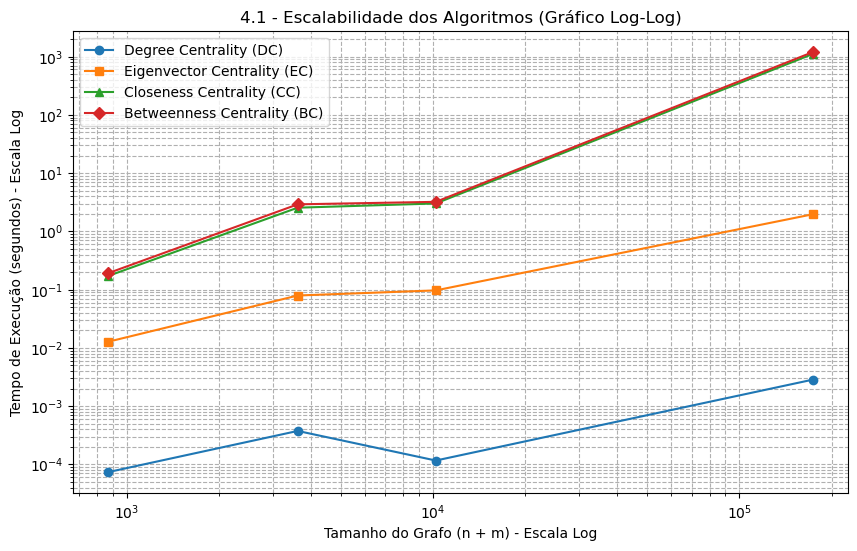

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt

print("A carregar os grafos da Marvel...")
g_marvel_small = carregar_grafo('marvel_small.csv')
g_marvel_full = carregar_grafo('marvel_full.csv')

analyzers = {
    'GoT Book 1': CentralityAnalyzer(g_book1),
    'GoT Full': CentralityAnalyzer(g_full),
    'Marvel Small': CentralityAnalyzer(g_marvel_small),
    'Marvel Full': CentralityAnalyzer(g_marvel_full)
}

tempos = {'DC': [], 'EC': [], 'CC': [], 'BC': []}
tamanhos_n_m = []
nomes_datasets = list(analyzers.keys())
k_iters = [] 

def medir_tempo(analyzer, metodo, nome_dataset):
    repeticoes = 1 if nome_dataset == 'Marvel Full' else 5
    tempos_medidos = []
    k_val = None
    
    for _ in range(repeticoes):
        inicio = time.time()
        if metodo == 'eigenvector_centrality':
            _, k_val = getattr(analyzer, metodo)()
        else:
            getattr(analyzer, metodo)()
        fim = time.time()
        tempos_medidos.append(fim - inicio)
        
    return np.median(tempos_medidos), k_val

print("A iniciar medições de tempo. Por favor aguarde (O Marvel Full vai demorar!)...")
for nome, analyzer in analyzers.items():
    print(f"A processar {nome}...")
    tamanhos_n_m.append(analyzer._n + analyzer._m)
    
    t_dc, _ = medir_tempo(analyzer, 'degree_centrality', nome)
    tempos['DC'].append(t_dc)
    
    t_ec, k = medir_tempo(analyzer, 'eigenvector_centrality', nome)
    tempos['EC'].append(t_ec)
    k_iters.append(k)
    
    t_cc, _ = medir_tempo(analyzer, 'closeness_centrality', nome)
    tempos['CC'].append(t_cc)
    
    t_bc, _ = medir_tempo(analyzer, 'betweenness_centrality', nome)
    tempos['BC'].append(t_bc)

print("Medições concluídas com sucesso!")

plt.figure(figsize=(10, 6))
plt.plot(tamanhos_n_m, tempos['DC'], marker='o', label='Degree Centrality (DC)')
plt.plot(tamanhos_n_m, tempos['EC'], marker='s', label='Eigenvector Centrality (EC)')
plt.plot(tamanhos_n_m, tempos['CC'], marker='^', label='Closeness Centrality (CC)')
plt.plot(tamanhos_n_m, tempos['BC'], marker='D', label='Betweenness Centrality (BC)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamanho do Grafo (n + m) - Escala Log')
plt.ylabel('Tempo de Execução (segundos) - Escala Log')
plt.title('4.1 - Escalabilidade dos Algoritmos (Gráfico Log-Log)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 4.2. Comparação Empírica CC vs BC

  A razão TBC/TCC compara diretamente o tempo de execução da Centralidade de Intermediação com o tempo de execução da Centralidade de Proximidade.

  Em teoria, ambos os algoritmos têm complexidade O(n · (n + m)) em grafos não ponderados, visto que ambos executam uma busca em largura (BFS) a partir de cada nó. Por essa razão, espera-se que seu crescimento seja similar com o aumento do tamanho do grafo.

  No entanto, a razão TBC/TCC não precisa ser constante em todos os conjuntos de dados. Isso ocorre porque a notação O(.) ignora constantes ocultas e detalhes de implementação. Embora CC e BC tenham a mesma complexidade assintótica, o algoritmo BC realiza operações adicionais que o CC não realiza.

  Em particular, o cálculo da medida Betweenness Centrality requer:
  a contagem do número de caminhos mínimos entre vértices;
  a manutenção de listas de predecessores;
  a soma de dependências;
  uma fase de retropropagação para cada BFS efetuada.

  O caso da medida Closeness Centrality é diferente, pois ela utiliza basicamente apenas as distâncias calculadas pelo BFS para realizar a soma das distâncias. Dessa forma, apesar de ter a mesma complexidade assintótica, a BC será sempre mais custosa.

  Dessa forma, caso a razão TBC/TCC seja superior a 1, é certo afirmar que a BC possui maiores constantes escondidas. Caso isso ocorra de forma não uniforme entre diferentes conjuntos de dados, isso seria devido às diferenças de estrutura dos grafos.

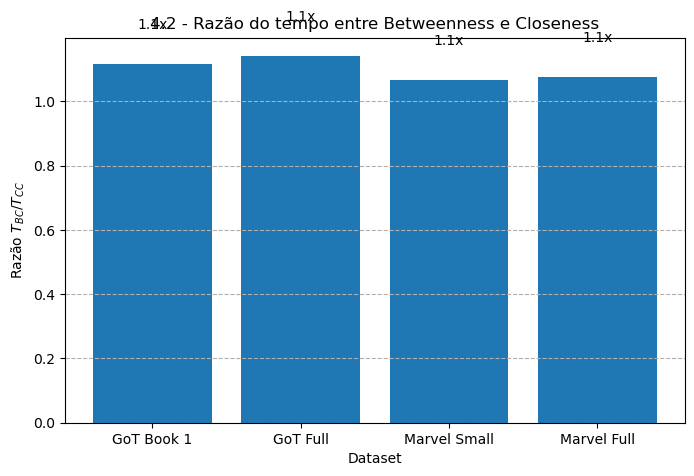

In [27]:
if 'tempos' not in globals() or 'nomes_datasets' not in globals():
    raise RuntimeError("Execute primeiro a célula da Secção 4.1 para criar as variáveis 'tempos' e 'nomes_datasets'.")

razao_bc_cc = [t_bc / t_cc if t_cc != 0 else float('inf')
               for t_bc, t_cc in zip(tempos['BC'], tempos['CC'])]

plt.figure(figsize=(8, 5))
plt.bar(nomes_datasets, razao_bc_cc)
for i, v in enumerate(razao_bc_cc):
    plt.text(i, v + 0.1, f"{v:.1f}x", ha='center', va='bottom')

plt.xlabel('Dataset')
plt.ylabel('Razão $T_{BC} / T_{CC}$')
plt.title('4.2 - Razão do tempo entre Betweenness e Closeness')
plt.grid(axis='y', linestyle='--')
plt.show()


## 4.3. Verificação $T_{CC}/T_{EC} \approx n/k$

  O relacionamento teórico esperado é:

  $T_{CC}/T_{EC} \approx n/k$

  Isso acontece porque a Closeness Centrality realiza BFSs começando por todos os n vértices. Como BFS custa O(n + m), a complexidade de tempo de CC será O(n · (n + m)).

  No entanto, a Eigenvector Centrality utiliza o método Power Iteration. Se a convergência ocorrer depois de k iterações e cada iteração custar O(n + m), a complexidade de tempo de EC será O(k · (n + m)).

  Em contrapartida, a Eigenvector Centrality utiliza a técnica de Power Iteration. Supondo que a convergência seja atingida em k iteracoes, com cada iteracao tendo complexidade O(n + m), o custo total para a EC seria aproximadamente O(k * (n + m)).

  Calculando a razão entre os dois custos, temos:

  $T_{CC}/T_{EC} \approx \frac{n \cdot (n+m)}{k \cdot (n+m)} = n/k$

  O gráfico de dispersão compara esta previsão teórica, n/k, com a razão TCC/TEC observada. O gráfico reta y = x atua como parâmetro de comparação: quanto mais perto se encontrar os pontos da reta, mais próximo estará a medida teórica à relação experimental observada.

  No entanto, é possível que não haja perfeita coincidência do ponto à reta y = x. Isso decorre das imprecisões no uso de uma análise assintótica, na qual são desconsideradas constantes ocultas e as características de implementação utilizadas. Por exemplo, a CC utiliza a utilização de filas e estruturas de BFS, enquanto a EC requer iterações de atualizações de scores e normalizações. Outro fator a considerar são as características estruturais dos próprios grafos.

  O fator k define o número de iterações requerido pela Eigenvector Centrality para convergir. Logo, se k for relativamente similar nos diversos conjuntos de dados, isto indicará que Power Iteration tem velocidade de convergência análoga em tais redes.

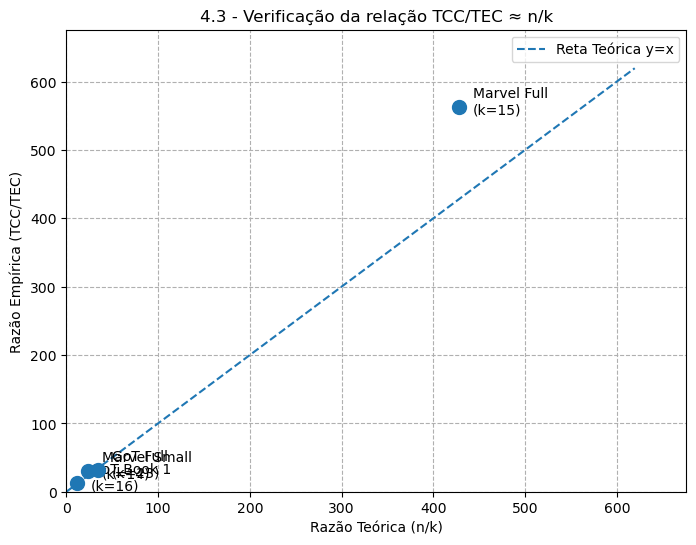

Comparação TCC/TEC vs n/k:
GoT Book 1: k=16, n/k=11.69, TCC/TEC=13.46
GoT Full: k=23, n/k=34.61, TCC/TEC=32.14
Marvel Small: k=14, n/k=23.36, TCC/TEC=31.03
Marvel Full: k=15, n/k=428.07, TCC/TEC=563.14


In [28]:
razao_cc_ec = [
    t_cc / t_ec if t_ec != 0 else float('inf')
    for t_cc, t_ec in zip(tempos['CC'], tempos['EC'])
]

n_sobre_k = [
    analyzer._n / k if k else float('inf')
    for analyzer, k in zip(analyzers.values(), k_iters)
]

plt.figure(figsize=(8, 6))
plt.scatter(n_sobre_k, razao_cc_ec, s=100, zorder=5)

for i, nome in enumerate(nomes_datasets):
    plt.annotate(
        f"{nome}\n(k={k_iters[i]})",
        (n_sobre_k[i], razao_cc_ec[i]),
        textcoords="offset points",
        xytext=(10, -5),
        ha='left'
    )

max_val = max(max(n_sobre_k), max(razao_cc_ec))

plt.plot(
    [0, max_val * 1.1],
    [0, max_val * 1.1],
    linestyle='--',
    label='Reta Teórica y=x'
)

plt.xlabel('Razão Teórica (n/k)')
plt.ylabel('Razão Empírica (TCC/TEC)')
plt.title('4.3 - Verificação da relação TCC/TEC ≈ n/k')
plt.legend()
plt.grid(True, linestyle='--')
plt.xlim(0, max_val * 1.2)
plt.ylim(0, max_val * 1.2)
plt.show()

print("Comparação TCC/TEC vs n/k:")
for nome, nk, razao, k in zip(nomes_datasets, n_sobre_k, razao_cc_ec, k_iters):
    print(f"{nome}: k={k}, n/k={nk:.2f}, TCC/TEC={razao:.2f}")


# 5. Questões Éticas

  A resolução deste trabalho obedeceu aos princípios de integridade académica, garantindo que todas as explicações, código e análises apresentadas refletem o esforço e compreensão do grupo.

  **5.1. Colaborações fora do grupo:**
  > (Nota para Daniel e Dinis: Indiquem aqui se tiveram ajuda de colegas de outros grupos para perceber a matéria. Se não, escrevam apenas "Nenhuma" ou "Não aplicável").

  **5.2. Fontes utilizadas:**
  > (Nota para Daniel e Dinis: Devem listar os materiais usados. Podem deixar os que já coloquei abaixo e acrescentar outros sites/livros se for caso disso).
  * Material disponibilizado na UC (Slides teóricos e laboratoriais).
  * Documento de apoio ao minitrabalho DAA 2025/2026.
  * Enunciado do Minitrabalho.